In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
# month = '8'
# with rasterio.open(f"/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/rainfall/monthly_rainfall_clim_statewide_1991-2020_{month}.tif") as src:
#     rf_climo = src.read(1)
#     nodata_climo = src.nodata
#     meta = src.meta.copy()

# masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

# with rasterio.open(f"../public/tifs/rainfall_2025_0{month}.tif") as src:
#     rf = src.read(1)
#     nodata_rf = src.nodata
#     transform = src.transform

# masked_rf = np.ma.masked_equal(rf, nodata_rf)

# pdiff = (masked_rf - masked_climo) / masked_climo * 100

# combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
# pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

# out_nodata = -9999 
# meta.update(
#     dtype="float32",
#     nodata=out_nodata
# )

# with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif", "w", **meta) as dst:
#     dst.write(pdiff_masked.filled(out_nodata).astype("float32"), 1)


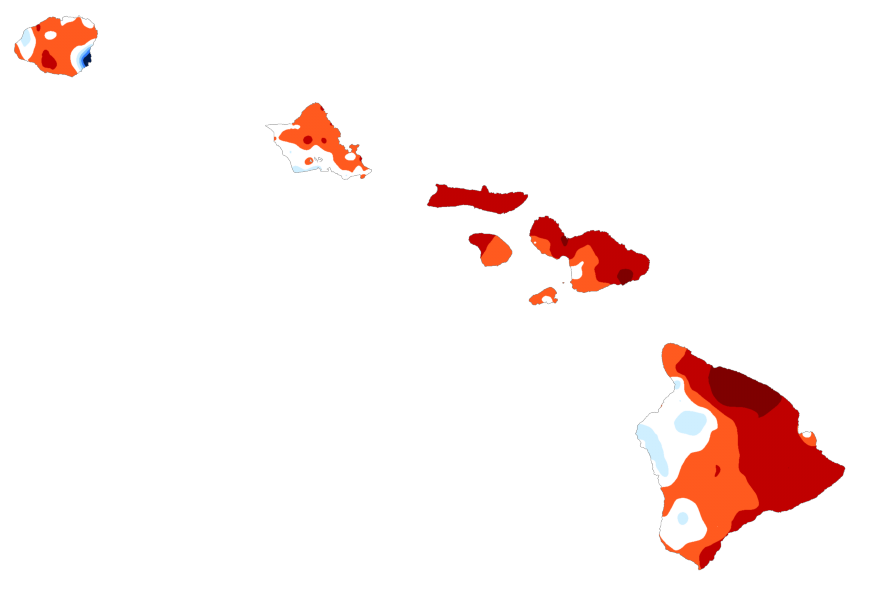

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -70, "#4b0000", "< -70%"),
    (-70,   -50, "#7f0000", "-70% to -50%"),
    (-50,   -30, "#c00000", "-50% to -30%"),
    (-30,   -10, "#ff5a1f", "-30% to -10%"),
    (-10,    10, "#ffffff", "-10% to 10%"),
    ( 10,    30, "#cfefff", "10% to 30%"),
    ( 30,    50, "#7fc3ff", "30% to 50%"),
    ( 50,    70, "#2f7dff", "50% to 70%"),
    ( 70,  np.inf, "#001a4d", "> 70%"),
]

with rasterio.open(f"annual_rainfall_2025_pdiff.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('../../public/climate-summary/annual_rainfall_2025_pdiff.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


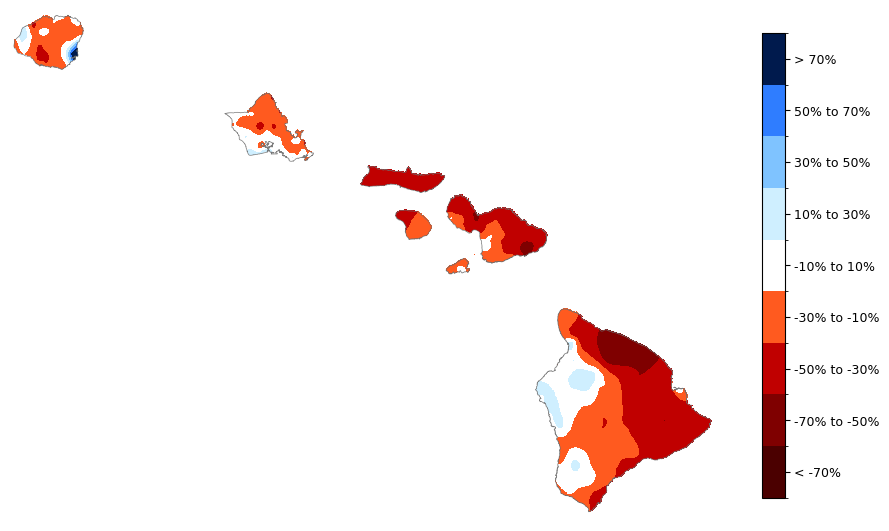

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent


# Save with legend for report + coastline outline

thresholds = [
    (-np.inf, -70, "#4b0000", "< -70%"),
    (-70,   -50, "#7f0000", "-70% to -50%"),
    (-50,   -30, "#c00000", "-50% to -30%"),
    (-30,   -10, "#ff5a1f", "-30% to -10%"),
    (-10,    10, "#ffffff", "-10% to 10%"),
    ( 10,    30, "#cfefff", "10% to 30%"),
    ( 30,    50, "#7fc3ff", "30% to 50%"),
    ( 50,    70, "#2f7dff", "50% to 70%"),
    ( 70,  np.inf, "#001a4d", "> 70%"),
]

tif_path = "annual_rainfall_2025_pdiff.tif"
coast_path = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public/shapefiles/Coastline.shp"
out_png = "../../public/climate-summary/pubs/Figure1.png"

with rasterio.open(tif_path) as src:
    data = src.read(1)
    nodata = src.nodata
    extent = rasterio.plot.plotting_extent(src)  # (left, right, bottom, top)
    raster_crs = src.crs

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

categorical_masked = np.ma.masked_where(categorical == 255, categorical)

# Read + reproject coastline to raster CRS
coast = gpd.read_file(coast_path)
if raster_crs is not None and coast.crs is not None and coast.crs != raster_crs:
    coast = coast.to_crs(raster_crs)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    categorical_masked,
    cmap=cmap,
    norm=norm,
    extent=extent,             # align raster with geodata
    interpolation="nearest",   # avoid halos
    resample=False
)

# Gray coastline outline (control width here)
coast.boundary.plot(
    ax=ax,
    color="#6e6e6e",
    linewidth=0.5,
    alpha=0.9
)

ax.set_axis_off()

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
fig.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()
